In [6]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings("ignore")
import cv2

In [2]:
# Define dataset paths
dir_sp_train = r"dataset/spiral/training"
dir_sp_test = r"dataset/spiral/testing"
dir_wv_train = r"dataset/wave/training"
dir_wv_test = r"dataset/wave/testing"

In [7]:
# Get class names
Name = []
for file in os.listdir(dir_sp_train):
    Name += [file]
print(Name)

['healthy', 'parkinson']


In [8]:
# Create label mappings
N = list(range(len(Name)))
normal_mapping = dict(zip(Name, N))
reverse_mapping = dict(zip(N, Name))

def mapper(value):
    return reverse_mapping[value]

Load and preprocess images from the spiral dataset (training and testing).

Training Data (dataset_sp):

Iterates through each class folder (healthy, parkinson) in dir_sp_train.

Assigns the numerical label using normal_mapping (e.g., healthy → 0, parkinson → 1).

Loads each image in grayscale mode with load_img and resizes it to 224x224 pixels (standard input size for VGG16).

Converts the image to a NumPy array using img_to_array. (Converts it into a NumPy array of shape (height, width, channels).)

Converts grayscale (1 channel) to RGB (3 channels) by repeating the grayscale channel three times (np.repeat(image, 3, axis=-1)), as VGG16 expects RGB input. (VGG16 was trained on ImageNet, which contains RGB images (shape: (height, width, 3)).)

Applies VGG16-specific preprocessing (preprocess_input), which normalizes pixel values (e.g., subtracts mean RGB values).

Appends a list [image, label] to dataset_sp.


Testing Data (testset_sp):

Follows the same process for the test directory (dir_sp_test).

Output: dataset_sp and testset_sp are lists where each element is [image_array, label].

In [9]:
# Load spiral dataset (grayscale, 224x224, convert to RGB for VGG16)
dataset_sp = []
for file in os.listdir(dir_sp_train):
    label = normal_mapping[file]
    path = os.path.join(dir_sp_train, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='grayscale', target_size=(224,224))
        image = img_to_array(image)
        # Convert grayscale to RGB by repeating the channel
        image = np.repeat(image, 3, axis=-1)
        image = preprocess_input(image)  # VGG16 preprocessing
        dataset_sp.append([image, label])

testset_sp = []
for file in os.listdir(dir_sp_test):
    label = normal_mapping[file]
    path = os.path.join(dir_sp_test, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='grayscale', target_size=(224,224))
        image = img_to_array(image)
        image = np.repeat(image, 3, axis=-1)
        image = preprocess_input(image)
        testset_sp.append([image, label])

In [33]:
# Load wave dataset (RGB, 100x100, preprocess for VGG16)
dataset_wv = []
for file in os.listdir(dir_wv_train):
    label = normal_mapping[file]
    path = os.path.join(dir_wv_train, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = preprocess_input(image)  # VGG16 preprocessing
        dataset_wv.append([image, label])

testset_wv = []
for file in os.listdir(dir_wv_test):
    label = normal_mapping[file]
    path = os.path.join(dir_wv_test, file)
    for im in os.listdir(path):
        image = load_img(os.path.join(path, im), color_mode='rgb', target_size=(100,100))
        image = img_to_array(image)
        image = preprocess_input(image)
        testset_wv.append([image, label])

Convert the spiral dataset into NumPy arrays suitable for model training.

In [11]:
# Prepare spiral data
data_sp, labels_sp0 = zip(*dataset_sp)
test_sp, tlabels_sp0 = zip(*testset_sp)
labels_sp1 = to_categorical(labels_sp0)
data_sp = np.array(data_sp)
labels_sp = np.array(labels_sp1)
tlabels_sp1 = to_categorical(tlabels_sp0)
test_sp = np.array(test_sp)
tlabels_sp = np.array(tlabels_sp1)

In [34]:
# Prepare wave data
data_wv, labels_wv0 = zip(*dataset_wv)
test_wv, tlabels_wv0 = zip(*testset_wv)
labels_wv1 = to_categorical(labels_wv0)
data_wv = np.array(data_wv)
labels_wv = np.array(labels_wv1)
tlabels_wv1 = to_categorical(tlabels_wv0)
test_wv = np.array(test_wv)
tlabels_wv = np.array(tlabels_wv1)

Split the training data into training and validation sets for both spiral and wave datasets.

In [35]:
# Split data
trainx_sp, testx_sp, trainy_sp, testy_sp = train_test_split(data_sp, labels_sp, test_size=0.2, random_state=44)
trainx_wv, testx_wv, trainy_wv, testy_wv = train_test_split(data_wv, labels_wv, test_size=0.2, random_state=44)

Verify the shapes of the training and validation sets to ensure correct data preparation.

In [36]:
# Print shapes
print("Spiral training shape:", trainx_sp.shape)
print("Spiral validation shape:", testx_sp.shape)
print("Spiral training labels shape:", trainy_sp.shape)
print("Spiral validation labels shape:", testy_sp.shape)
print("Wave training shape:", trainx_wv.shape)
print("Wave validation shape:", testx_wv.shape)
print("Wave training labels shape:", trainy_wv.shape)
print("Wave validation labels shape:", testy_wv.shape)

Spiral training shape: (57, 224, 224, 3)
Spiral validation shape: (15, 224, 224, 3)
Spiral training labels shape: (57, 2)
Spiral validation labels shape: (15, 2)
Wave training shape: (57, 100, 100, 3)
Wave validation shape: (15, 100, 100, 3)
Wave training labels shape: (57, 2)
Wave validation labels shape: (15, 2)


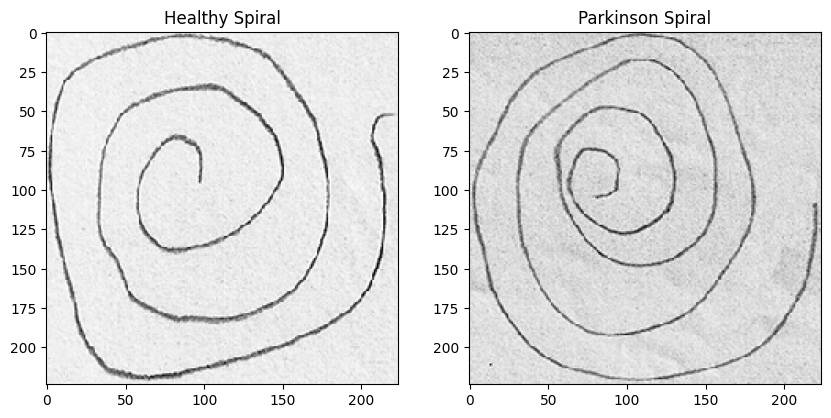

In [15]:
# Visualize sample images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
healthy_idx = list(labels_sp0).index(0)  # First healthy sample
plt.imshow(data_sp[healthy_idx][:,:,0], cmap='gray')
plt.title('Healthy Spiral')
plt.subplot(1,2,2)
parkinson_idx = list(labels_sp0).index(1)  # First parkinson sample
plt.imshow(data_sp[parkinson_idx][:,:,0], cmap='gray')
plt.title('Parkinson Spiral')
plt.show()

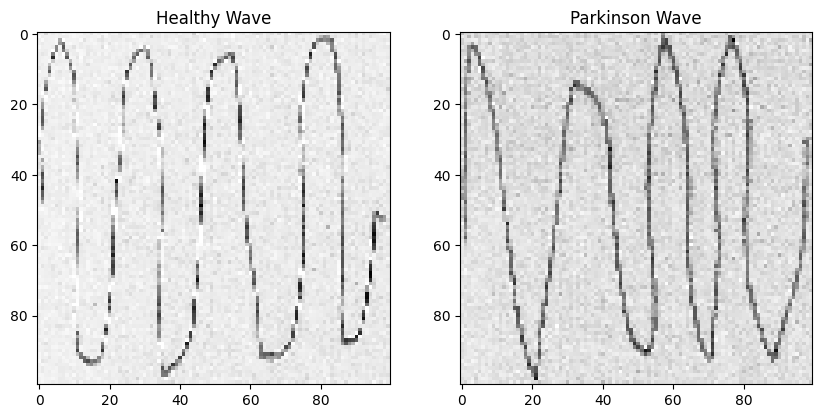

In [37]:
# Visualize sample wave images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
healthy_idx_wv = list(labels_wv0).index(0)  # First healthy sample
plt.imshow(data_wv[healthy_idx_wv][:,:,0], cmap='gray')
plt.title('Healthy Wave')
plt.subplot(1,2,2)
parkinson_idx_wv = list(labels_wv0).index(1)  # First parkinson sample
plt.imshow(data_wv[parkinson_idx_wv][:,:,0], cmap='gray')
plt.title('Parkinson Wave')
plt.show()

VGG16 -
pretrained VGG16, you get:
A ready-to-use model with useful visual knowledge
Faster training and better performance, even with small datasets
The ability to fine-tune it for your custom task (e.g., Parkinson detection)
simplicity and effectiveness
it has learned useful visual features (like edges, textures, shapes) that can be transferred to other tasks — like medical image classification.
limited data
Easy to modify or fine-tune
Computationally efficient on modern hardware

Load the pre-trained VGG16 model as the base for transfer learning.

Freeze the weights of the VGG16 base model to prevent them from being updated during training.

Define a custom CNN model (model3) by adding layers on top of the VGG16 base model for binary classification.

Configure the model for training by specifying the loss function, optimizer, and evaluation metrics.

Display a summary of the model’s architecture, including the number of parameters and layer details.

In [16]:
# Define spiral model with VGG16
print("Spiral VGG16 Model Build")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze VGG16 weights
model3 = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model3.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
print("Model Summary")
model3.summary()


Spiral VGG16 Model Build
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Define a custom CNN model (model3) from scratch for binary classification of grayscale spiral images.

Configure the model for training by specifying the loss function, optimizer, and evaluation metrics.

In [11]:
# Define spiral model (simplified, grayscale input)
print("Spiral CNN Model Build")
model3 = Sequential([
    Conv2D(32, (5,5), activation="relu", input_shape=(150,150,1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.6),
    Dense(2, activation="softmax")
])

model3.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
print("Model Summary")
model3.summary()

Spiral CNN Model Build
Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 146, 146, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 146, 146, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 71, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 78400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,035,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,055,298 (38.36 MB)

 Trainable params: 10,055,106 (38.36 MB)

 Non-trainable params: 192 (768.00 B)

Create an ImageDataGenerator object to apply real-time data augmentation to the spiral training images, enhancing the robustness of the model

In [17]:
# Data augmentation for spiral training
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

Configure an EarlyStopping callback to halt training if the model's performance on the validation set stops improving, thus preventing overfitting and saving computational resources.

Configure a ReduceLROnPlateau callback to dynamically reduce the learning rate when the validation loss stops improving, aiding convergence to a better solution.

In [19]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

In [20]:
# Train spiral model
print("Start Spiral Training \n")
history = model3.fit(datagen.flow(trainx_sp, trainy_sp, batch_size=32),
                     validation_data=(testx_sp, testy_sp),
                     epochs=50,
                     callbacks=[early_stopping, lr_scheduler])

Start Spiral Training 

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step - accuracy: 0.4395 - loss: 8.6048 - val_accuracy: 0.6000 - val_loss: 5.9014 - learning_rate: 1.0000e-04
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step - accuracy: 0.5397 - loss: 6.1378 - val_accuracy: 0.8667 - val_loss: 3.3123 - learning_rate: 1.0000e-04
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 10s/step - accuracy: 0.6398 - loss: 5.4925 - val_accuracy: 0.8667 - val_loss: 3.0291 - learning_rate: 1.0000e-04
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 31s 18s/step - accuracy: 0.5956 - loss: 5.2221 - val_accuracy: 0.8667 - val_loss: 2.9818 - learning_rate: 1.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 11s/step - accuracy: 0.7750 - loss: 4.0421 - val_accuracy: 0.8000 - val_loss: 3.1635 - learning_rate: 1.0000e-04
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 10s/step - accuracy: 0.7796 - loss: 3.7651 - val_accuracy: 0.8000 - val_loss: 3.1810 - learning_rate: 1.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 10s/step - accuracy:

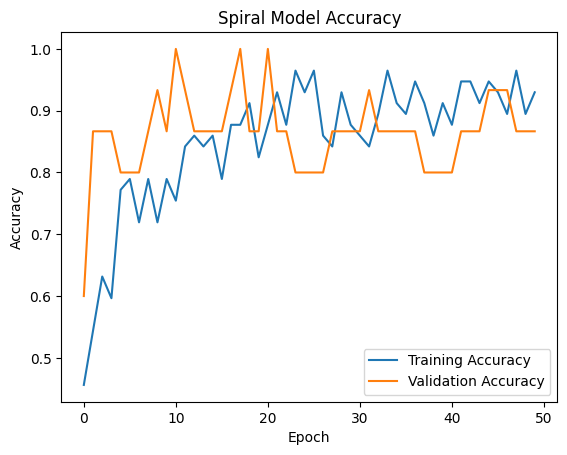

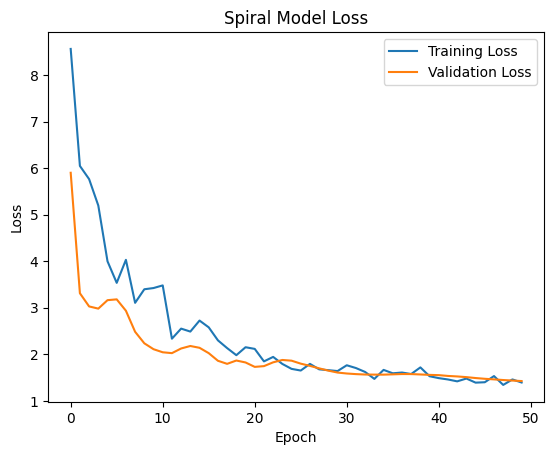

In [21]:
# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Spiral Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Spiral Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Evaluate spiral model
print(test_sp.shape)
pred_sp = model3.predict(test_sp)
pred_labels_sp = np.argmax(pred_sp, axis=1)
print("Confusion Matrix:")
print(confusion_matrix(tlabels_sp0, pred_labels_sp))
print("\nClassification Report:")
print(classification_report(tlabels_sp0, pred_labels_sp, target_names=['healthy', 'parkinson']))

(30, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Confusion Matrix:
[[12  3]
 [ 3 12]]

Classification Report:
              precision    recall  f1-score   support

     healthy       0.80      0.80      0.80        15
   parkinson       0.80      0.80      0.80        15

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.80      0.80      0.80        30



In [23]:
# Test on a single healthy sample
image_sp = load_img(r"dataset/spiral/testing/healthy/V01HE01.png", target_size=(224,224), color_mode='grayscale')
image_sp = img_to_array(image_sp)
image_sp = np.repeat(image_sp, 3, axis=-1)
image_sp = preprocess_input(image_sp)
image_sp = np.expand_dims(image_sp, axis=0)
pred_sp = model3.predict(image_sp)
print("Prediction for V01HE01.png:", mapper(np.argmax(pred_sp)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
Prediction for V01HE01.png: healthy


In [24]:
# Test on a single parkinson sample
image_sp2 = load_img(r"dataset/spiral/testing/parkinson/V09PE01.png", target_size=(224,224), color_mode='grayscale')
image_sp2 = img_to_array(image_sp2)
image_sp2 = np.repeat(image_sp2, 3, axis=-1)
image_sp2 = preprocess_input(image_sp2)
image_sp2 = np.expand_dims(image_sp2, axis=0)
pred_sp2 = model3.predict(image_sp2)
print("Prediction for V09PE01.png:", mapper(np.argmax(pred_sp2)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Prediction for V09PE01.png: parkinson


In [38]:
# Define wave model with VGG16
print("Wave VGG16 Model Build")
base_model_wv = VGG16(weights='imagenet', include_top=False, input_shape=(100,100,3))
base_model_wv.trainable = False  # Freeze VGG16 weights
model4 = Sequential([
    base_model_wv,
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

Wave VGG16 Model Build


In [39]:
model4.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
print("Wave Model Summary")
model4.summary()

Wave Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,304,898 (58.38 MB)

 Trainable params: 590,210 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
# Data augmentation for wave training
datagen_wv = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [41]:
# Train wave model
print("Start Wave Training \n")
early_stopping_wv = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler_wv = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
history_wv = model4.fit(datagen_wv.flow(trainx_wv, trainy_wv, batch_size=32),
                       validation_data=(testx_wv, testy_wv),
                       epochs=50,
                       callbacks=[early_stopping_wv, lr_scheduler_wv])

Start Wave Training 

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5476 - loss: 5.1860 - val_accuracy: 0.7333 - val_loss: 3.5968 - learning_rate: 1.0000e-04
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5747 - loss: 5.3025 - val_accuracy: 0.8000 - val_loss: 3.4077 - learning_rate: 1.0000e-04
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6528 - loss: 4.8235 - val_accuracy: 0.8000 - val_loss: 3.3155 - learning_rate: 1.0000e-04
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6073 - loss: 5.2869 - val_accuracy: 0.8667 - val_loss: 3.0728 - learning_rate: 1.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6243 - loss: 5.2763 - val_accuracy: 0.8667 - val_loss: 2.8714 - learning_rate: 1.0000e-04
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6944 - loss: 4.6742 - val_accuracy: 0.8667 - val_loss: 2.7272 - learning_rate: 1.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.6344 - loss

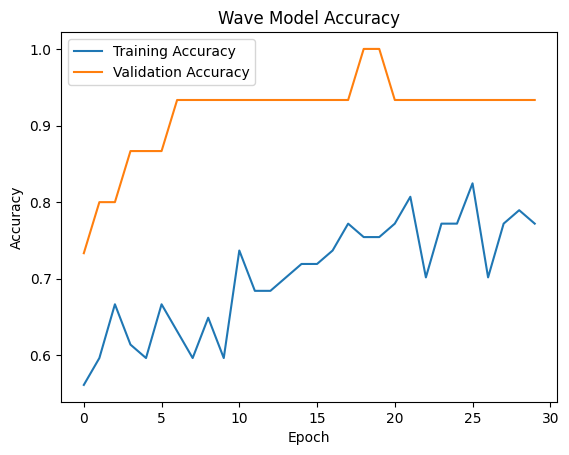

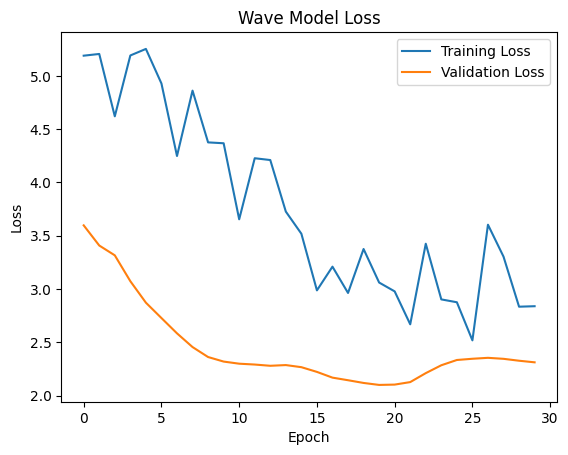

In [42]:
# Plot wave training history
plt.plot(history_wv.history['accuracy'], label='Training Accuracy')
plt.plot(history_wv.history['val_accuracy'], label='Validation Accuracy')
plt.title('Wave Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_wv.history['loss'], label='Training Loss')
plt.plot(history_wv.history['val_loss'], label='Validation Loss')
plt.title('Wave Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [43]:
# Evaluate wave model
print("Wave test shape:", test_wv.shape)
pred_wv = model4.predict(test_wv)
pred_labels_wv = np.argmax(pred_wv, axis=1)
print("Wave Confusion Matrix:")
print(confusion_matrix(tlabels_wv0, pred_labels_wv))
print("\nWave Classification Report:")
print(classification_report(tlabels_wv0, pred_labels_wv, target_names=['healthy', 'parkinson']))

Wave test shape: (30, 100, 100, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Wave Confusion Matrix:
[[11  4]
 [ 1 14]]

Wave Classification Report:
              precision    recall  f1-score   support

     healthy       0.92      0.73      0.81        15
   parkinson       0.78      0.93      0.85        15

    accuracy                           0.83        30
   macro avg       0.85      0.83      0.83        30
weighted avg       0.85      0.83      0.83        30



In [32]:
# Test wave sample
image2 = load_img(r"dataset/wave/testing/parkinson/V14PO03.png", target_size=(100,100))
image2 = img_to_array(image2)
image2 = image2/255.0
prediction_image2 = np.array(image2)
prediction_image2 = np.expand_dims(image2, axis=0)
prediction2 = model4.predict(prediction_image2)
value2 = np.argmax(prediction2)
move_name2 = mapper(value2)
print("Prediction is {}.".format(move_name2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction is healthy.


In [44]:
# Test wave sample
image_wv = load_img(r"dataset/wave/testing/parkinson/V14PO03.png", target_size=(100,100))
image_wv = img_to_array(image_wv)
image_wv = preprocess_input(image_wv)
image_wv = np.expand_dims(image_wv, axis=0)
prediction_wv = model4.predict(image_wv)
value_wv = np.argmax(prediction_wv)
move_name_wv = mapper(value_wv)
print("Prediction for V14PO03.png (wave):", move_name_wv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Prediction for V14PO03.png (wave): parkinson


In [45]:
# Test wave sample
image_wv = load_img(r"dataset/wave/testing/healthy/V09HO01.png", target_size=(100,100))
image_wv = img_to_array(image_wv)
image_wv = preprocess_input(image_wv)
image_wv = np.expand_dims(image_wv, axis=0)
prediction_wv = model4.predict(image_wv)
value_wv = np.argmax(prediction_wv)
move_name_wv = mapper(value_wv)
print("Prediction for V14PO03.png (wave):", move_name_wv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Prediction for V14PO03.png (wave): healthy


In [46]:
model3.save(r'spiral_model.h5')
model4.save(r'wave_model.h5')

In [ ]:
# Save spiral model
model3.save(r'spiral_model.keras')
# Save wave model
model4.save(r'wave_model.keras')

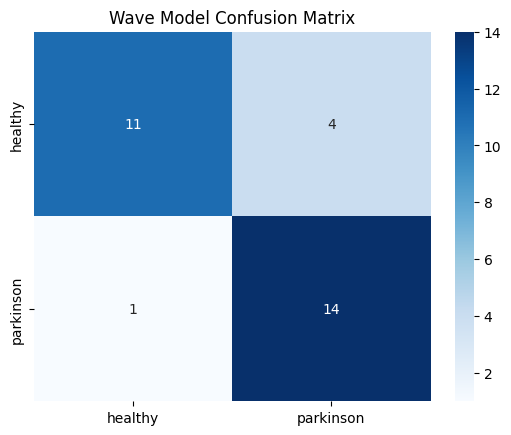

In [51]:
# Confusion Matrix Plot

import seaborn as sns
cm = confusion_matrix(tlabels_wv0, pred_labels_wv)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['healthy', 'parkinson'], yticklabels=['healthy', 'parkinson'])
plt.title('Wave Model Confusion Matrix')
plt.show()



In [53]:
# Combined prediction function for spiral and wave images
def predict_combined(spiral_model, wave_model, spiral_path, wave_path):
    try:
        # Load and preprocess spiral image (grayscale, 224x224, convert to RGB)
        if not os.path.exists(spiral_path):
            raise FileNotFoundError(f"Spiral image not found: {spiral_path}")
        spiral_img = load_img(spiral_path, color_mode='grayscale', target_size=(224,224))
        spiral_img = img_to_array(spiral_img)
        spiral_img = np.repeat(spiral_img, 3, axis=-1)
        spiral_img = preprocess_input(spiral_img)
        spiral_img = np.expand_dims(spiral_img, axis=0)

        # Load and preprocess wave image (RGB, 100x100)
        if not os.path.exists(wave_path):
            raise FileNotFoundError(f"Wave image not found: {wave_path}")
        wave_img = load_img(wave_path, color_mode='rgb', target_size=(100,100))
        wave_img = img_to_array(wave_img)
        wave_img = preprocess_input(wave_img)
        wave_img = np.expand_dims(wave_img, axis=0)

        # Predict with both models
        spiral_pred = spiral_model.predict(spiral_img, verbose=0)
        wave_pred = wave_model.predict(wave_img, verbose=0)

        # Average probabilities
        avg_probs = (spiral_pred + wave_pred) / 2
        final_label = np.argmax(avg_probs)
        final_diagnosis = mapper(final_label)
        spiral_label = mapper(np.argmax(spiral_pred))
        wave_label = mapper(np.argmax(wave_pred))

        # Display images and predictions
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(img_to_array(load_img(spiral_path, color_mode='grayscale', target_size=(224,224)))[:,:,0], cmap='gray')
        plt.title(f"Spiral: {spiral_label}\nHealthy: {spiral_pred[0][0]:.3f}, Parkinson: {spiral_pred[0][1]:.3f}")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(img_to_array(load_img(wave_path, color_mode='rgb', target_size=(100,100))))
        plt.title(f"Wave: {wave_label}\nHealthy: {wave_pred[0][0]:.3f}, Parkinson: {wave_pred[0][1]:.3f}")
        plt.axis('off')
        plt.suptitle(f"Final Diagnosis: {final_diagnosis} (Healthy: {avg_probs[0][0]:.3f}, Parkinson: {avg_probs[0][1]:.3f})")
        plt.show()

        return {
            'final_diagnosis': final_diagnosis,
            'final_probabilities': {'healthy': float(avg_probs[0][0]), 'parkinson': float(avg_probs[0][1])},
            'spiral_prediction': spiral_label,
            'spiral_probabilities': {'healthy': float(spiral_pred[0][0]), 'parkinson': float(spiral_pred[0][1])},
            'wave_prediction': wave_label,
            'wave_probabilities': {'healthy': float(wave_pred[0][0]), 'parkinson': float(wave_pred[0][1])}
        }
    except Exception as e:
        print(f"Error: {str(e)}")
        return None

Combining Predictions

avg_probs = (spiral_pred + wave_pred) / 2

spiral_pred: Probability vector from model3 (e.g., [0.95, 0.05]).
wave_pred: Probability vector from model4 (e.g., [0.15, 0.85]).
avg_probs: Element-wise average (e.g., [(0.95 + 0.15)/2, (0.05 + 0.85)/2] = [0.55, 0.45]).


Example Combined Prediction:


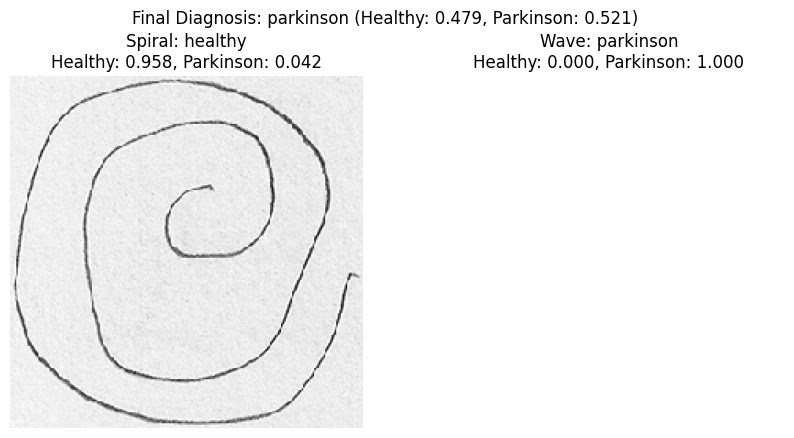

Final Diagnosis: parkinson, Probabilities: healthy=0.479, parkinson=0.521
Spiral Prediction: healthy, Probabilities: healthy=0.958, parkinson=0.042
Wave Prediction: parkinson, Probabilities: healthy=0.000, parkinson=1.000


In [56]:
# Example combined prediction
print("\nExample Combined Prediction:")
result = predict_combined(model3, model4,
                         r"dataset/spiral/testing/healthy/V01HE01.png",
                         r"dataset/wave/testing/parkinson/V14PO03.png")
if result:
    print(f"Final Diagnosis: {result['final_diagnosis']}, "
          f"Probabilities: healthy={result['final_probabilities']['healthy']:.3f}, "
          f"parkinson={result['final_probabilities']['parkinson']:.3f}")
    print(f"Spiral Prediction: {result['spiral_prediction']}, "
          f"Probabilities: healthy={result['spiral_probabilities']['healthy']:.3f}, "
          f"parkinson={result['spiral_probabilities']['parkinson']:.3f}")
    print(f"Wave Prediction: {result['wave_prediction']}, "
          f"Probabilities: healthy={result['wave_probabilities']['healthy']:.3f}, "
          f"parkinson={result['wave_probabilities']['parkinson']:.3f}")

In [55]:
!pip show tensorflow numpy h5py streamlit pillow matplotlib

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\hp\AppData\Roaming\Python\Python311\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 
---
Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain 